In [1]:
import pandas as pd

In [3]:
dataset = pd.read_csv('Position_Salaries.csv')

In [4]:
dataset.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [5]:
X = dataset.iloc[:, 1:2].values
Y = dataset.iloc[:, 2].values

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=123)

In [8]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
y_pred = model.predict(X_test)

Text(0.5, 1.0, 'Salary vs Experience')

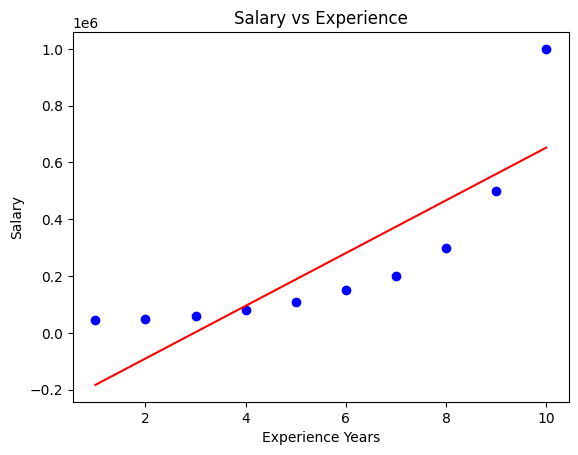

In [10]:
import matplotlib.pyplot as plt
plt.scatter(X, Y, color='blue', label='Data Points')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.title('Salary vs Experience')

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score
print("\n=== Linear Regression Results ===")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")


=== Linear Regression Results ===
MAE: 153232.48
MSE: 29136287983.29
RMSE: 29136287983.29
R² Score: -26.5847


In [12]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=4)
X_poly_train = poly_features.fit_transform(X_train)
X_poly_test = poly_features.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)

LinearRegression()

In [13]:
poly_pred = poly_model.predict(X_poly_test)

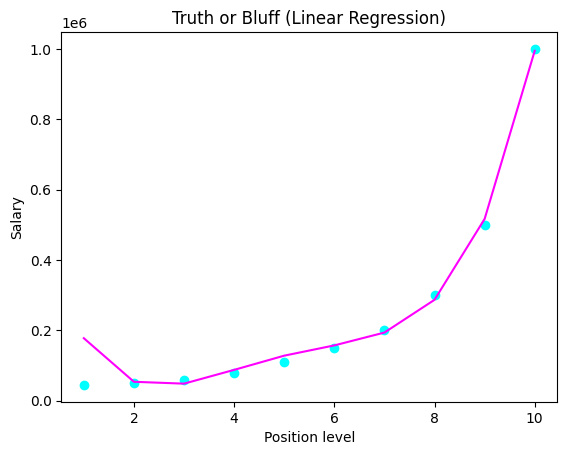

In [14]:
# Visualizing the Polymonial Regression results
def viz_polymonial():
    plt.scatter(X, Y, color='cyan')
    plt.plot(X, poly_model.predict(poly_features.fit_transform(X)), color='magenta')
    plt.title('Truth or Bluff (Linear Regression)')
    plt.xlabel('Position level')
    plt.ylabel('Salary')
    plt.show()
    return
viz_polymonial()

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score

print("MAE:", mean_absolute_error(y_test, poly_pred))
print("RMSE:", root_mean_squared_error(y_test, poly_pred))
print("MAPE:", mean_absolute_percentage_error(y_test, poly_pred))
print("R²:", r2_score(y_test, poly_pred))

MAE: 75468.31127142475
RMSE: 94762.02275898482
MAPE: 1.5578488454512407
R²: -7.501624575028977
